# FEEC basics

This tutorial provides a practical introduction to working with finite element exterior calculus (FEEC) in Struphy. It covers the fundamental concepts and tools you need to set up and manipulate the discrete de Rham complex.

**Prerequisite knowledge**: Familiarity with the mathematical concepts of FEEC is helpful. For comprehensive background, see [the numerics section of the Struphy documentation](https://struphy-hub.github.io/struphy/sections/subsections/numerics-geomFE.html) and the references therein.

**What you'll learn**:
1. How to set up a `Derham` object and understand its key attributes
2. How to access 1D spline space information via `SplineSpace1D`
3. How to create callable spline functions for evaluation
4. How to use differential operators (grad, curl, div)
5. How to work with geometric projectors and the commuting property

This tutorial is the foundation for more advanced FEEC work, such as boundary condition handling (see the [boundary conditions tutorial](dev_tutorial_feec_bcs.ipynb)).

## 1. Setting up a Derham object

The `Derham` class creates the discrete de Rham complex—a fundamental data structure in FEEC that contains all the finite element spaces and operators you need.

To create a `Derham` object, you need two things:
1. A spatial grid (`TensorProductGrid`)
2. Configuration options (`DerhamOptions`)

Let's start with a simple 1D domain with 16 elements:

In [1]:
from struphy.feec.psydac_derham import Derham
from struphy.topology.grids import TensorProductGrid
from struphy.io.options import DerhamOptions

# Create a 1D grid with 16 elements
grid = TensorProductGrid(num_elements=(16, 1, 1))

# Create default Derham object with default options
derham_opts = DerhamOptions()
derham = Derham(grid, derham_opts)

print("Derham object created successfully")
print(f"Grid has {derham.grid.num_elements} elements")

Derham object created successfully
Grid has (16, 1, 1) elements


### Default configuration

By default, the `Derham` object uses spline degree $p=1$ in each direction:

In [2]:
print(f"Spline degrees: {derham.degree}")

Spline degrees: (1, 1, 1)


And periodic boundary conditions (no constraints) in all directions:

In [3]:
print(f"Boundary conditions: {derham.bcs}")

Boundary conditions: (None, None, None)


Let's also check the quadrature configuration used for numerical integration:

In [4]:
print(f"Quadrature points per direction: {derham.nquads}")

Quadrature points per direction: (2, 2, 2)


## 2. Understanding Derham attributes and SplineSpace1D

The `Derham` object provides several important attributes for accessing the discrete spaces and their properties.

### 2.1 Space identifiers (`space_to_form`)

FEEC organizes spaces by the differential form degree they support. The mapping from space identifier to form degree is:

In [5]:
print("Space to form mapping:")
for space_id, form_degree in derham.space_to_form.items():
    print(f"  {space_id:4s} -> form degree {form_degree}")

Space to form mapping:
  H1   -> form degree 0
  Hcurl -> form degree 1
  Hdiv -> form degree 2
  L2   -> form degree 3
  H1vec -> form degree v


### 2.2 Discrete function spaces (`Vh`)

The `Vh` dictionary contains the vector spaces (from Psydac's `psydac.linalg`) where finite element coefficients live. Each space corresponds to one of the de Rham spaces:

In [6]:
print("Discrete spaces (Vh):")
for space_id, V in derham.coeff_spaces.items():
    if space_id in derham.space_to_form:
        print(f"  {space_id:4s}: {V}")

Discrete spaces (Vh):
  H1  : <feectools.linalg.stencil.StencilVectorSpace object at 0x7ff620721630>
  Hcurl: <feectools.linalg.block.BlockVectorSpace object at 0x7ff61e9336d0>
  Hdiv: <feectools.linalg.block.BlockVectorSpace object at 0x7ff61e96df60>
  L2  : <feectools.linalg.stencil.StencilVectorSpace object at 0x7ff61e96f9d0>
  H1vec: <feectools.linalg.block.BlockVectorSpace object at 0x7ff61e96faf0>


### 2.3 Polar spaces (`Vh_pol`)

In addition to Cartesian spaces, FEEC can handle polar coordinates. These spaces are available via `Vh_pol` (if they have been initialized):

In [7]:
print("Polar spaces (Vh_pol):")
if derham.polar_coeff_spaces is not None:
    for space_id, V in derham.polar_coeff_spaces.items():
        if space_id in derham.space_to_form:
            print(f"  {space_id:4s}: {V}")
else:
    print("  Polar spaces not initialized (None)")

Polar spaces (Vh_pol):
  H1  : <feectools.linalg.stencil.StencilVectorSpace object at 0x7ff620721630>
  Hcurl: <feectools.linalg.block.BlockVectorSpace object at 0x7ff61e9336d0>
  Hdiv: <feectools.linalg.block.BlockVectorSpace object at 0x7ff61e96df60>
  L2  : <feectools.linalg.stencil.StencilVectorSpace object at 0x7ff61e96f9d0>
  H1vec: <feectools.linalg.block.BlockVectorSpace object at 0x7ff61e96faf0>


### 2.4 1D spline space information (`SplineSpace1D`)

One powerful feature of Struphy is the ability to access information about the 1D spline spaces underlying the 3D tensor product construction. Each de Rham space corresponds to a different combination of 1D spline space types in the three directions.

The spline space types are accessed via attributes like `V0splines`, `V1splines`, `V2splines`, and `V3splines`:

In [8]:
# Access the 0-form (H1) spline space information
V0_splines = derham.V0splines
print("H1 space (0-forms):")
print(f"  Type: {type(V0_splines)}")

H1 space (0-forms):
  Type: <class 'struphy.feec.psydac_derham.SplineAttributes1D'>


These `SplineSpace1D` objects contain detailed information about the 1D tensor product construction:

In [9]:
# Each direction's spline space info is stored in separate components
print("\nQuadrature grid points per direction (for H1 space):")
quad_pts = V0_splines.quad_grid_pts
for i, pts_tuple in enumerate(quad_pts):
    if isinstance(pts_tuple, tuple):
        print(f"  Direction {i}: {len(pts_tuple)} components")
        for j, pts in enumerate(pts_tuple):
            print(f"    Component {j}: {len(pts)} quadrature points")
    else:
        print(f"  Direction {i}: {len(pts_tuple)} quadrature points")


Quadrature grid points per direction (for H1 space):
  Direction 0: 3 components
    Component 0: 16 quadrature points
    Component 1: 1 quadrature points
    Component 2: 1 quadrature points


Let's examine spline space types across all four de Rham spaces and the additional space `H1vec`:

In [10]:
spaces = {'H1': derham.V0splines, 
          'Hcurl': derham.V1splines, 
          'Hdiv': derham.V2splines, 
          'L2': derham.V3splines,
          'H1vec': derham.Vvsplines}

for name, space_info in spaces.items():
    print(f"\n{name} space (spline types):")
    print(f"  Spline types: {space_info.spline_types}")
    print(f"  Number components: {len(space_info.quad_grid_pts)}")


H1 space (spline types):
  Spline types: (('B', 'B', 'B'),)
  Number components: 1

Hcurl space (spline types):
  Spline types: (('M', 'B', 'B'), ('B', 'M', 'B'), ('B', 'B', 'M'))
  Number components: 3

Hdiv space (spline types):
  Spline types: (('B', 'M', 'M'), ('M', 'B', 'M'), ('M', 'M', 'B'))
  Number components: 3

L2 space (spline types):
  Spline types: (('M', 'M', 'M'),)
  Number components: 1

H1vec space (spline types):
  Spline types: (('B', 'B', 'B'), ('B', 'B', 'B'), ('B', 'B', 'B'))
  Number components: 3


### 2.5 Commuting projectors

The projectors that respect the de Rham sequence are accessible via the `projectors` attribute:

In [11]:
print("Commuting projectors:")
for space_id, proj in derham.projectors.items():
    if space_id in derham.space_to_form.values():
        print(f"  P_{space_id}: {proj}")

Commuting projectors:
  P_0: <struphy.feec.projectors.CommutingProjector object at 0x7ff61ea080a0>
  P_1: <struphy.feec.projectors.CommutingProjector object at 0x7ff61ea08610>
  P_2: <struphy.feec.projectors.CommutingProjector object at 0x7ff61ea08b20>
  P_3: <struphy.feec.projectors.CommutingProjector object at 0x7ff61ea0a3b0>
  P_v: <struphy.feec.projectors.CommutingProjector object at 0x7ff61c700280>


## 3. Creating and evaluating callable spline functions

Once you have a `Derham` object, you can create callable spline functions. These are wrapper objects that allow you to evaluate finite element solutions at arbitrary points in the domain.

### 3.1 Define a test function

Let's define a simple test function that we'll project into different spaces:

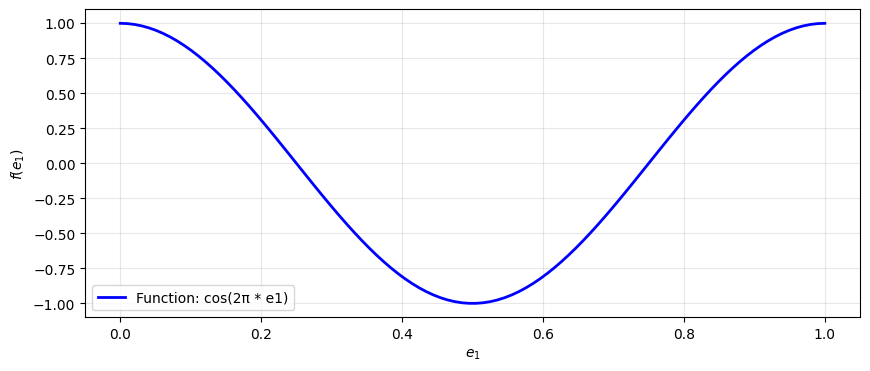

In [12]:
import numpy as np
from matplotlib import pyplot as plt

# Define a test function
fun = lambda e1, e2, e3: np.cos(2 * np.pi * e1)

# Evaluation points
e1 = np.linspace(0, 1, 100)
e2 = 0.5
e3 = 0.5

# Plot the function
plt.figure(figsize=(10, 4))
plt.plot(e1, fun(e1, e2, e3), 'b-', linewidth=2, label='Function: cos(2π * e1)')
plt.xlabel('$e_1$')
plt.ylabel('$f(e_1)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.2 Project the function into the H1 space

Use the `P0` projector to project the function into the discrete H1 space:

In [13]:
# Project into H1 space (0-forms)
vec = derham.P0(fun)
print(f"Projected vector type: {type(vec)}")
print(f"Vector shape: {vec.shape}")
print(f"Vector as numpy array shape: {vec[:].shape}")

Projected vector type: <class 'feectools.linalg.stencil.StencilVector'>
Vector shape: (np.int64(16),)
Vector as numpy array shape: (18, 3, 3)


The result is a `StencilVector` (Psydac's distributed vector type). For developers, the `.toarray()` method converts it to a regular numpy array for inspection:

In [14]:
arr = vec.toarray()
print(f"Coefficients as numpy array: shape {arr.shape}")
print(f"First 10 coefficients: {arr[:10]}")

Coefficients as numpy array: shape (16,)
First 10 coefficients: [ 1.00000000e+00  9.23879533e-01  7.07106781e-01  3.82683432e-01
  6.12323400e-17 -3.82683432e-01 -7.07106781e-01 -9.23879533e-01
 -1.00000000e+00 -9.23879533e-01]


### 3.3 Create a callable spline function

To evaluate the finite element function at arbitrary points, create a `SplineFunction` object using `create_spline_function()`:

In [15]:
# Create a callable spline function
fun_h = derham.create_spline_function(
    name="test_function",
    space_id="H1",
    coeffs=vec,
)

print(f"Created spline function: {fun_h}")

Created spline function: <struphy.feec.psydac_derham.SplineFunction object at 0x7ff61c703d30>


### 3.4 Evaluate the spline function

Now you can evaluate the finite element function at arbitrary points:

In [16]:
# Evaluate the spline function at the same points
fun_h_values = fun_h(e1, e2, e3, squeeze_out=True)

print("\nEvaluation results:")
print(f"  Type: {type(fun_h_values)}")
print(f"  Shape: {fun_h_values.shape}")
print(f"  First 5 values: {fun_h_values[:5]}")


Evaluation results:
  Type: <class 'numpy.ndarray'>
  Shape: (100,)
  First 5 values: [1.         0.9876977  0.9753954  0.96309311 0.95079081]


### 3.5 Compare exact and projected functions

Let's visualize the quality of the projection:

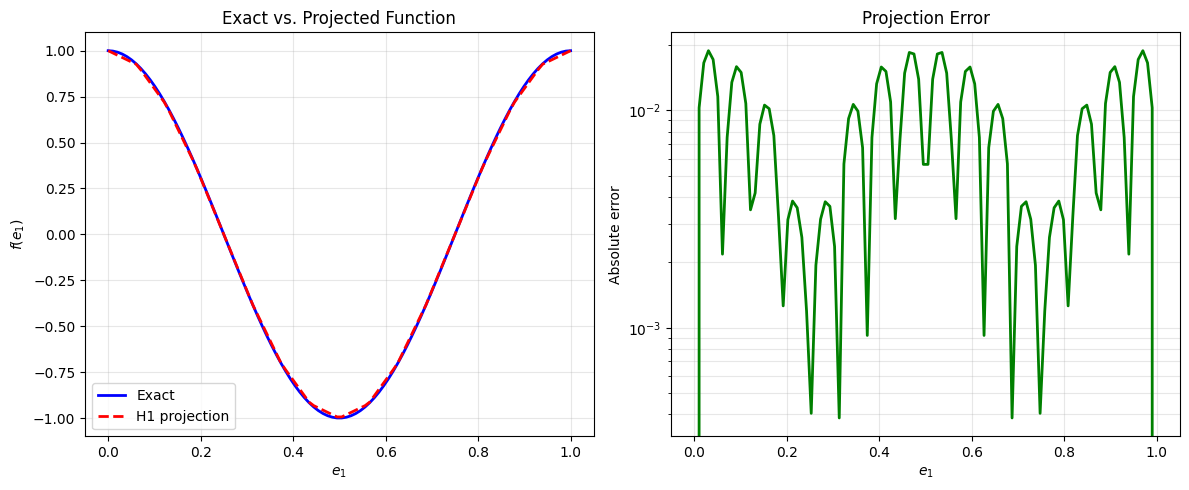

Maximum error: 1.88e-02
Relative error: 1.88e-02


In [17]:
# Compute exact values and projection
exact_vals = fun(e1, e2, e3)
proj_vals = fun_h(e1, e2, e3, squeeze_out=True)

# Plot comparison
plt.figure(figsize=(12, 5))

# Left plot: comparison
plt.subplot(1, 2, 1)
plt.plot(e1, exact_vals, 'b-', linewidth=2, label='Exact')
plt.plot(e1, proj_vals, 'r--', linewidth=2, label='H1 projection')
plt.xlabel('$e_1$')
plt.ylabel('$f(e_1)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Exact vs. Projected Function')

# Right plot: error
plt.subplot(1, 2, 2)
error = np.abs(exact_vals - proj_vals)
plt.semilogy(e1, error, 'g-', linewidth=2)
plt.xlabel('$e_1$')
plt.ylabel('Absolute error')
plt.grid(True, alpha=0.3, which='both')
plt.title('Projection Error')

plt.tight_layout()
plt.show()

print(f"Maximum error: {error.max():.2e}")
print(f"Relative error: {error.max() / np.abs(exact_vals).max():.2e}")

## 4. Differential operators: Grad, Curl, and Div

The discrete de Rham complex contains differential operators connecting the different spaces. These are accessible as attributes of the `Derham` object.

### 4.1 The Grad operator ($\nabla$)

The gradient operator maps from H1 (0-forms) to Hcurl (1-forms):

In [18]:
# Access the gradient operator
grad_op = derham.grad
print(f"Gradient operator: {grad_op}")
print(f"Domain (input space): {grad_op.domain}")
print(f"Codomain (output space): {grad_op.codomain}")

Gradient operator: <feectools.linalg.block.BlockLinearOperator object at 0x7ff61e96fd60>
Domain (input space): <feectools.linalg.stencil.StencilVectorSpace object at 0x7ff620721630>
Codomain (output space): <feectools.linalg.block.BlockVectorSpace object at 0x7ff61e9336d0>


Apply the gradient operator to a vector of coefficients using the `.dot()` method:

In [19]:
# First project a function into H1
scalar_fun = lambda e1, e2, e3: np.cos(2 * np.pi * e1)
scalar_vec = derham.P0(scalar_fun)

# Apply gradient: H1 -> Hcurl
grad_vec = derham.grad.dot(scalar_vec)
print("\nGradient of scalar function:")
print(f"  Input type: {type(scalar_vec)}, space dimension: {scalar_vec.shape}")
print(f"  Output type: {type(grad_vec)}, space dimension: {grad_vec.shape}")


Gradient of scalar function:
  Input type: <class 'feectools.linalg.stencil.StencilVector'>, space dimension: (np.int64(16),)
  Output type: <class 'feectools.linalg.block.BlockVector'>, space dimension: (np.int64(48),)


Create a callable 1-form function to visualize the gradient:

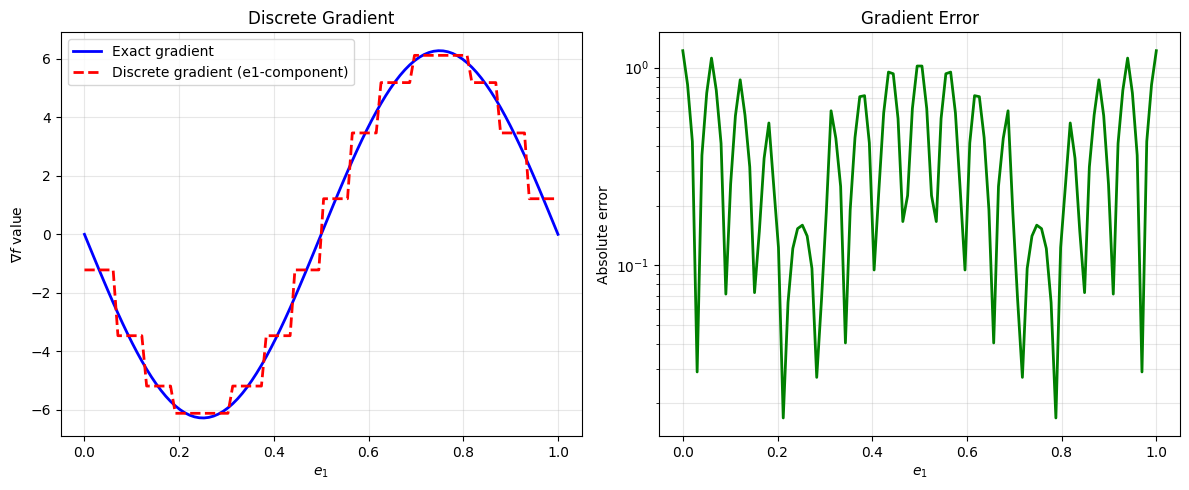

Maximum gradient error: 1.22e+00


In [20]:
# Create callable gradient function
grad_fun = derham.create_spline_function(
    name="gradient",
    space_id="Hcurl",
    coeffs=grad_vec,
)

# Evaluate the gradient
grad_vals = grad_fun(e1, e2, e3, squeeze_out=True)

# The analytical gradient is -2π * sin(2π * e1)
exact_grad = -2 * np.pi * np.sin(2 * np.pi * e1)

# Plot the gradient
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(e1, exact_grad, 'b-', linewidth=2, label='Exact gradient')
plt.plot(e1, grad_vals[0], 'r--', linewidth=2, label='Discrete gradient (e1-component)')
plt.xlabel('$e_1$')
plt.ylabel('$\\nabla f$ value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Discrete Gradient')

plt.subplot(1, 2, 2)
error_grad = np.abs(exact_grad - grad_vals[0])
plt.semilogy(e1, error_grad, 'g-', linewidth=2)
plt.xlabel('$e_1$')
plt.ylabel('Absolute error')
plt.grid(True, alpha=0.3, which='both')
plt.title('Gradient Error')

plt.tight_layout()
plt.show()

print(f"Maximum gradient error: {error_grad.max():.2e}")

### 4.2 The Curl operator ($\nabla \times$)

The curl operator maps from Hcurl (1-forms) to Hdiv (2-forms):

In [21]:
# Access the curl operator
curl_op = derham.curl
print(f"Curl operator: {curl_op}")
print(f"Domain (input space): {curl_op.domain}")
print(f"Codomain (output space): {curl_op.codomain}")

Curl operator: <feectools.linalg.block.BlockLinearOperator object at 0x7ff61e96e8c0>
Domain (input space): <feectools.linalg.block.BlockVectorSpace object at 0x7ff61e9336d0>
Codomain (output space): <feectools.linalg.block.BlockVectorSpace object at 0x7ff61e96df60>


To demonstrate curl, we need a vector function. Let's create one:

In [22]:
# Define a vector field (3 components, one for each e_i direction)
u1 = lambda e1, e2, e3: np.sin(2 * np.pi * e1) * np.cos(2 * np.pi * e2)      # varies in e1, e2
u2 = lambda e1, e2, e3: np.cos(2 * np.pi * e1) * np.sin(2 * np.pi * e3)      # varies in e1, e3
u3 = lambda e1, e2, e3: np.sin(2 * np.pi * e2) * np.cos(2 * np.pi * e3)      # varies in e2, e3

# Project vector field into Hcurl space
vector_vec = derham.P1((u1, u2, u3))

# Apply curl: Hcurl -> Hdiv
curl_vec = derham.curl.dot(vector_vec)
print("\nCurl of vector field:")
print(f"  Input type: {type(vector_vec)}, space dimension: {vector_vec.shape}")
print(f"  Output type: {type(curl_vec)}, space dimension: {curl_vec.shape}")


Curl of vector field:
  Input type: <class 'feectools.linalg.block.BlockVector'>, space dimension: (np.int64(48),)
  Output type: <class 'feectools.linalg.block.BlockVector'>, space dimension: (np.int64(48),)


### 4.3 The Div operator ($\nabla \cdot$)

The divergence operator maps from Hdiv (2-forms) to L2 (3-forms):

In [23]:
# Access the divergence operator
div_op = derham.div
print(f"Divergence operator: {div_op}")
print(f"Domain (input space): {div_op.domain}")
print(f"Codomain (output space): {div_op.codomain}")

Divergence operator: <feectools.linalg.block.BlockLinearOperator object at 0x7ff61e96e1a0>
Domain (input space): <feectools.linalg.block.BlockVectorSpace object at 0x7ff61e96df60>
Codomain (output space): <feectools.linalg.stencil.StencilVectorSpace object at 0x7ff61e96f9d0>


To demonstrate divergence, we need a 2-form (which represents a vector normal to surfaces). Let's create one by projecting a vector field into Hdiv:

In [24]:
# Define a vector field to project into Hdiv
v1 = lambda e1, e2, e3: np.sin(2 * np.pi * e1) * (1 - e1)              # varies with e1
v2 = lambda e1, e2, e3: np.cos(2 * np.pi * e2) * np.sin(2 * np.pi * e3)    # varies with e2, e3
v3 = lambda e1, e2, e3: (1 - e1) * np.cos(2 * np.pi * e3)              # varies with e1, e3

# Project into Hdiv space (2-forms)
hdiv_vec = derham.P2((v1, v2, v3))

# Apply divergence: Hdiv -> L2
div_vec = derham.div.dot(hdiv_vec)
print("\nDivergence of 2-form:")
print(f"  Input type: {type(hdiv_vec)}, space dimension: {hdiv_vec.shape}")
print(f"  Output type: {type(div_vec)}, space dimension: {div_vec.shape}")
print(f"  Output is a 3-form (scalar): dimension {div_vec.shape}")


Divergence of 2-form:
  Input type: <class 'feectools.linalg.block.BlockVector'>, space dimension: (np.int64(48),)
  Output type: <class 'feectools.linalg.stencil.StencilVector'>, space dimension: (np.int64(16),)
  Output is a 3-form (scalar): dimension (np.int64(16),)


## 5. Commuting projectors: P0, P1, P2, P3

The geometric projectors P0, P1, P2, P3 project functions into each of the four de Rham spaces. These projectors **commute** with the differential operators, which is a fundamental property of FEEC.

Let's demonstrate this with a simple 1D example:

### 5.1 Projecting a scalar function

Use `P0` to project into the H1 space (0-forms):

In [25]:
# Define scalar function
scalar = lambda e1, e2, e3: 0.5 * np.sin(4 * np.pi * e1)

# Project into H1
phi_h = derham.P0(scalar)
print(f"P0 (H1 space):    dimension = {phi_h.shape}")

P0 (H1 space):    dimension = (np.int64(16),)


### 5.2 Projecting the gradient

The analytical gradient can be projected into Hcurl using `P1`:

In [26]:
# Define the analytical gradient
dx = lambda e1, e2, e3: 4 * np.pi * 0.5 * np.cos(4 * np.pi * e1)  # derivative in e1 direction
dy = lambda e1, e2, e3: np.zeros_like(e1)                                  # zero in other directions
dz = lambda e1, e2, e3: np.zeros_like(e1)

# Project gradient into Hcurl
grad_phi_h = derham.P1((dx, dy, dz))
print(f"P1 (Hcurl space): dimension = {grad_phi_h.shape}")

P1 (Hcurl space): dimension = (np.int64(48),)


### 5.3 Using all five projectors

Here's a summary of the four projectors for the 0, 1, 2, 3-form and vector spaces:

In [27]:
# Define test functions for each space
f0 = lambda e1, e2, e3: np.sin(2 * np.pi * e1)
f1 = lambda e1, e2, e3: np.cos(2 * np.pi * e2)
f2 = lambda e1, e2, e3: np.cos(2 * np.pi * e3)

# Apply all projectors
v0 = derham.P0(f0)  # -> H1
v1 = derham.P1((f0, f1, f2))  # -> Hcurl
v2 = derham.P2((f0, f1, f2))  # -> Hdiv
v3 = derham.P3(f0)  # -> L2
vv = derham.Pv((f0, f1, f2))  # -> H1 vector space

print("Projections into all de Rham spaces:")
print(f"  P0 (H1):    {v0.shape}")
print(f"  P1 (Hcurl): {v1.shape}")
print(f"  P2 (Hdiv):  {v2.shape}")
print(f"  P3 (L2):    {v3.shape}")
print(f"  Pv (H1):    {vv.shape}")

Projections into all de Rham spaces:
  P0 (H1):    (np.int64(16),)
  P1 (Hcurl): (np.int64(48),)
  P2 (Hdiv):  (np.int64(48),)
  P3 (L2):    (np.int64(16),)
  Pv (H1):    (np.int64(48),)


## 6. The Commuting Property

One of the fundamental properties of FEEC is that the geometric projectors **commute** with the differential operators. This means:

$$\mathbb P_1(\nabla f) = \nabla (\mathbb P_0(f))$$

for any function $f$. Let's verify this numerically:

### 6.1 Define a test function and its gradient

We'll use the sinusoidal function and compute its gradient analytically:

In [28]:
# Test function: f(e1) = 0.5 * sin(2π * 2 * e1)
def fun(e1, e2, e3):
    return 0.5 * np.sin(4 * np.pi * e1)

# Analytical gradient (with zero components in other directions)
dx = lambda e1, e2, e3: 4 * np.pi * 0.5 * np.cos(4 * np.pi * e1)
dy = lambda e1, e2, e3: np.zeros_like(e1)
dz = lambda e1, e2, e3: np.zeros_like(e1)

print("Test function: f(e1) = 0.5 * sin(4π e1)")
print("Analytical gradient: ∇f = (0.5 * 4π * cos(4π e1), 0, 0)")

Test function: f(e1) = 0.5 * sin(4π e1)
Analytical gradient: ∇f = (0.5 * 4π * cos(4π e1), 0, 0)


### 6.2 Verify commutativity both ways

We compute $\nabla(P_0(f))$ and $P_1(\nabla f)$ and check that they're equal:

In [29]:
# Method 1: Project then apply gradient
fun_h = derham.P0(fun)                        # Project function into H1
grad_fun_h = derham.grad.dot(fun_h)           # Apply discrete gradient

# Method 2: Apply gradient then project
dfun_h = derham.P1((dx, dy, dz))                      # Project gradient into Hcurl

print("Method 1 (project, then differentiate):")
print(f"  Intermediate: P0(f) with shape {fun_h.shape}")
print(f"  Result:       grad(P0(f)) with shape {grad_fun_h.shape}")
print()
print("Method 2 (differentiate, then project):")
print(f"  Result:       P1(∇f) with shape {dfun_h.shape}")

Method 1 (project, then differentiate):
  Intermediate: P0(f) with shape (np.int64(16),)
  Result:       grad(P0(f)) with shape (np.int64(48),)

Method 2 (differentiate, then project):
  Result:       P1(∇f) with shape (np.int64(48),)


### 6.3 Compare the two methods

Check that both methods give the same result by comparing their coefficients:

In [30]:
# Convert to arrays for comparison
method1 = grad_fun_h.toarray()
method2 = dfun_h.toarray()

print("Verification of commutativity:")
print(f"  Method 1 coefficients (e1 component): {method1[:10]}")
print(f"  Method 2 coefficients (e1 component): {method2[:10]}")
print()

# Check if they're numerically close
is_commuting = np.allclose(method1, method2)
print(f"✓ Commuting property verified: {is_commuting}")
if is_commuting:
    max_diff = np.abs(method1 - method2).max()
    print(f"  Maximum coefficient difference: {max_diff:.2e}")
else:
    print(f"  Maximum coefficient difference: {np.abs(method1 - method2).max():.2e}")

Verification of commutativity:
  Method 1 coefficients (e1 component): [ 0.35355339  0.14644661 -0.14644661 -0.35355339 -0.35355339 -0.14644661
  0.14644661  0.35355339  0.35355339  0.14644661]
  Method 2 coefficients (e1 component): [ 0.35352163  0.14643345 -0.14643345 -0.35352163 -0.35352163 -0.14643345
  0.14643345  0.35352163  0.35352163  0.14643345]

✓ Commuting property verified: False
  Maximum coefficient difference: 3.18e-05


### 6.4 Visualize the commuting property

Let's evaluate both solutions at points and plot them to see the agreement visually:

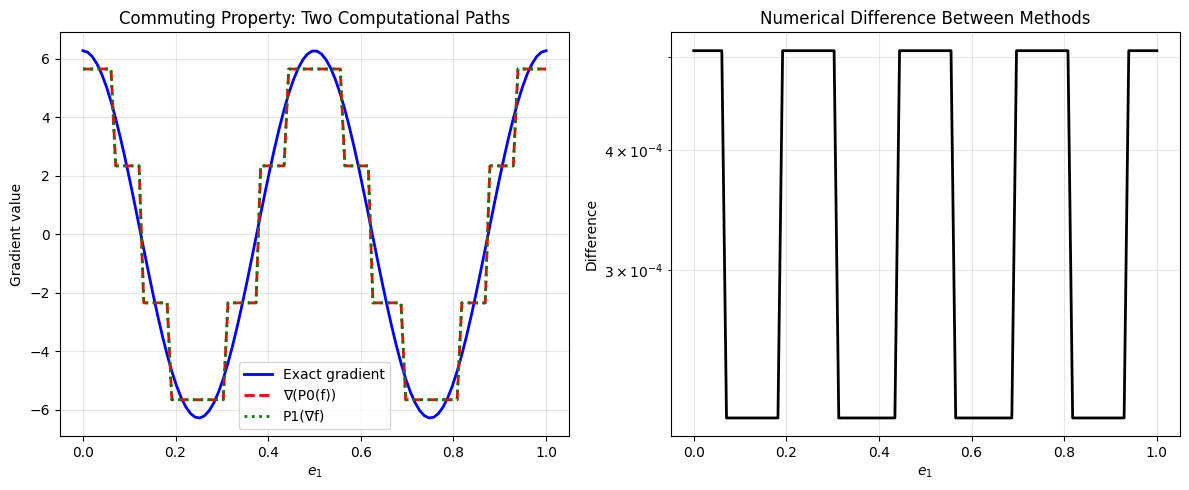

Maximum difference between methods: 5.08e-04


In [31]:
# Create callable functions for both methods
grad_via_method1 = derham.create_spline_function("grad(P0(f))", "Hcurl", grad_fun_h)
grad_via_method2 = derham.create_spline_function("P1(∇f)", "Hcurl", dfun_h)

# Evaluation points
e1_eval = np.linspace(0, 1, 100)
e2_eval = 0.5
e3_eval = 0.5

# Evaluate both methods
val1 = grad_via_method1(e1_eval, e2_eval, e3_eval, squeeze_out=True)
val2 = grad_via_method2(e1_eval, e2_eval, e3_eval, squeeze_out=True)
dx_exact = dx(e1_eval, e2_eval, e3_eval)
dy_exact = dy(e1_eval, e2_eval, e3_eval)
dz_exact = dz(e1_eval, e2_eval, e3_eval)

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(e1_eval, dx_exact, 'b-', linewidth=2, label='Exact gradient')
plt.plot(e1_eval, val1[0], 'r--', linewidth=2, label='∇(P0(f))')
plt.plot(e1_eval, val2[0], 'g:', linewidth=2, label='P1(∇f)')
plt.xlabel('$e_1$')
plt.ylabel('Gradient value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Commuting Property: Two Computational Paths')

plt.subplot(1, 2, 2)
diff = np.abs(val1[0] - val2[0])
plt.semilogy(e1_eval, diff, 'k-', linewidth=2)
plt.xlabel('$e_1$')
plt.ylabel('Difference')
plt.grid(True, alpha=0.3, which='both')
plt.title('Numerical Difference Between Methods')

plt.tight_layout()
plt.show()

print(f"Maximum difference between methods: {diff.max():.2e}")

## Summary

In this tutorial, you learned:

1. **Derham setup** — Create a Derham object using TensorProductGrid and DerhamOptions
2. **Attributes and SplineSpace1D** — Inspect spaces, access 1D spline information, understand the tensor product structure
3. **Callable spline functions** — Project functions into discrete spaces and evaluate them at arbitrary points
4. **Differential operators** — Apply grad, curl, and div operators to discrete functions
5. **Commuting projectors** — Use P0, P1, P2, P3 to project into the four de Rham spaces
6. **Commuting property** — Verify the fundamental FEEC property that projectors commute with derivatives

These concepts form the foundation for using FEEC in Struphy for physics simulations. For boundary condition handling and more advanced topics, see the [boundary conditions tutorial](dev_tutorial_feec_bcs.ipynb).